# HIPS Residuals vs Chemistry and Aethalometer Spectral Metrics


In [1]:
NOTEBOOK_STEM = "03_residuals_chemistry_spectral_metrics"


Objective: test whether HIPS residuals or HIPS/FTIR ratios track chemistry
(OC/EC, Fe, soil tracers) or aethalometer spectral metrics (UV/IR, Delta-C,
raw ATN AAE). This bridges the source/dust/organic threads to the core HIPS anomaly.


In [2]:
from pathlib import Path
import sys
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

REPO_ROOT = Path("/Users/ahmadjalil/github/aethmodular")
FTIR_DIR = REPO_ROOT / "research" / "ftir_hips_chem"
CATCH_UP_DIR = REPO_ROOT / "research" / "catch_up"
DATA_ROOT = Path('/Users/ahmadjalil/Library/CloudStorage/GoogleDrive-ahzs645@gmail.com/My Drive/University/Research/Grad/UC Davis Ann/NASA MAIA/Data')
OUT_DIR = CATCH_UP_DIR / "output" / globals().get("NOTEBOOK_STEM", Path.cwd().name)
OUT_DIR.mkdir(parents=True, exist_ok=True)

SCRIPTS_DIR = FTIR_DIR / "scripts"
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

from config import SITES
from outliers import apply_exclusion_flags, apply_threshold_flags, get_clean_data
from plotting import PlotConfig, apply_default_style

apply_default_style()
PlotConfig.set(sites="all", layout="individual", show_stats=True, show_1to1=True)

SITE_CODES = {site: cfg["code"] for site, cfg in SITES.items()}
CODE_TO_SITE = {v: k for k, v in SITE_CODES.items()}
SITE_COLORS = {site: PlotConfig.get_site_color(site) for site in SITE_CODES}

PARAM_RENAME = {
    "EC_ftir": "ftir_ec",
    "OC_ftir": "ftir_oc",
    "HIPS_Fabs": "hips_fabs",
    "HIPS_T1": "hips_t1",
    "HIPS_R1": "hips_r1",
    "HIPS_t": "hips_t",
    "HIPS_r": "hips_r",
    "HIPS_tau": "hips_tau",
    "ChemSpec_EC_PM2.5": "chemspec_ec",
    "ChemSpec_OC_PM2.5": "chemspec_oc",
    "ChemSpec_OM_PM2.5": "chemspec_om",
    "ChemSpec_Iron_PM2.5": "iron",
    "ChemSpec_Silicon_PM2.5": "silicon",
    "ChemSpec_Aluminum_PM2.5": "aluminum",
    "ChemSpec_Calcium_PM2.5": "calcium",
    "ChemSpec_Titanium_PM2.5": "titanium",
    "ChemSpec_Filter_PM2.5_mass": "pm25_mass",
}

def _first_existing(paths):
    for p in paths:
        if Path(p).exists():
            return Path(p)
    raise FileNotFoundError("None of these paths exist:\n" + "\n".join(map(str, paths)))

def load_filter_long():
    path = _first_existing([
        FTIR_DIR / "Filter Data" / "unified_filter_dataset.pkl",
        DATA_ROOT / "Combine csv files" / "Filter Data" / "unified_filter_dataset.pkl",
        DATA_ROOT / "Combine csv files" / "FTIR_HIPS_Chem" / "Filter Data" / "unified_filter_dataset.pkl",
    ])
    df = pd.read_pickle(path)
    df["SampleDate"] = pd.to_datetime(df["SampleDate"])
    df["base_filter_id"] = df["FilterId"].astype(str).str.replace(r"-\d+$", "", regex=True)
    print(f"Loaded filter data: {path}  rows={len(df):,}")
    return df

def load_filter_wide(params):
    long = load_filter_long()
    d = long[long["Parameter"].isin(params)].copy()
    meta = (
        d.sort_values(["Site", "base_filter_id", "SampleDate"])
         .groupby(["Site", "base_filter_id"], as_index=False)
         .agg(
             filter_id=("FilterId", "first"),
             date=("SampleDate", "first"),
             volume_m3=("Volume_m3", "max"),
             deposit_area_cm2=("DepositArea_cm2", "max"),
             lot_id=("LotId", "first"),
         )
    )
    conc = d.pivot_table(
        index=["Site", "base_filter_id"],
        columns="Parameter",
        values="Concentration",
        aggfunc="first",
    ).rename(columns=PARAM_RENAME)
    mass = d.pivot_table(
        index=["Site", "base_filter_id"],
        columns="Parameter",
        values="MassLoading_ug",
        aggfunc="first",
    ).rename(columns={p: PARAM_RENAME.get(p, p) + "_mass_ug" for p in params})
    wide = meta.merge(conc.reset_index(), on=["Site", "base_filter_id"], how="left")
    wide = wide.merge(mass.reset_index(), on=["Site", "base_filter_id"], how="left")
    wide["site"] = wide["Site"].map(CODE_TO_SITE)
    return wide

def load_aeth_site(site):
    file_map = {
        "Beijing": "df_Beijing_9am_resampled.pkl",
        "Delhi": "df_Delhi_9am_resampled.pkl",
        "JPL": "df_JPL_9am_resampled.pkl",
        "Addis_Ababa": "df_Addis_Ababa_9am_resampled.pkl",
    }
    repo_path = FTIR_DIR / "processed_sites" / file_map[site]
    cloud_candidates = [
        DATA_ROOT / "Aethelometry Data" / "JacrosMA350 60s Data20250804082112" / "df_Jacros_9am_resampled.pkl",
        DATA_ROOT / "Aethelometry Data" / "Kyan Data" / "Dataset" / "df_cleaned_Beijing_manual_BCc.pkl",
        DATA_ROOT / "Aethelometry Data" / "Kyan Data" / "Dataset" / "df_cleaned_Delhi_manual_BCc.pkl",
        DATA_ROOT / "Aethelometry Data" / "Kyan Data" / "Dataset" / "df_cleaned_JPL_manual_BCc.pkl",
    ]
    path = repo_path if repo_path.exists() else _first_existing([p for p in cloud_candidates if site.replace("_Ababa", "") in p.name or site == "Addis_Ababa"])
    df = pd.read_pickle(path)
    df = df.loc[:, ~df.columns.duplicated()].copy()
    if "day_9am" in df.columns:
        df["date"] = pd.to_datetime(df["day_9am"]).dt.normalize()
    elif "datetime_local" in df.columns:
        df["date"] = pd.to_datetime(df["datetime_local"]).dt.normalize()
    else:
        df["date"] = pd.to_datetime(df.index).normalize()
    df["site"] = site
    return df

def _to_ugm3(s):
    s = pd.to_numeric(s, errors="coerce")
    med = s.dropna().abs().median()
    return s / 1000.0 if pd.notna(med) and med > 100 else s

def aeth_metrics(site):
    df = load_aeth_site(site)
    out = df[["site", "date"]].copy()
    for wl in ["UV", "Blue", "Green", "Red", "IR"]:
        col = f"{wl} BCc"
        out[f"{wl.lower()}_bc_ugm3"] = _to_ugm3(df[col]) if col in df.columns else np.nan
    out["aeth_ir_ugm3"] = out["ir_bc_ugm3"]
    out["uv_ir_bcc_ratio"] = out["uv_bc_ugm3"] / out["ir_bc_ugm3"]
    out["green_ir_bcc_ratio"] = out["green_bc_ugm3"] / out["ir_bc_ugm3"]
    out["delta_c_ugm3"] = out["uv_bc_ugm3"] - out["ir_bc_ugm3"]
    # Raw attenuation-based apparent AAE from rolling mean dATN when available.
    uv = pd.to_numeric(df.get("delta UV ATN1 rolling mean", np.nan), errors="coerce")
    ir = pd.to_numeric(df.get("delta IR ATN1 rolling mean", np.nan), errors="coerce")
    mask = (uv > 0) & (ir > 0)
    out["aae_atn_uv_ir"] = np.where(mask, -np.log(uv / ir) / np.log(375 / 880), np.nan)
    return out.groupby(["site", "date"], as_index=False).median(numeric_only=True)

def matched_dataset(include_chem=True):
    params = ["EC_ftir", "OC_ftir", "HIPS_Fabs", "HIPS_T1", "HIPS_R1", "HIPS_t", "HIPS_r", "HIPS_tau"]
    if include_chem:
        params += [
            "ChemSpec_EC_PM2.5", "ChemSpec_OC_PM2.5", "ChemSpec_OM_PM2.5",
            "ChemSpec_Iron_PM2.5", "ChemSpec_Silicon_PM2.5", "ChemSpec_Aluminum_PM2.5",
            "ChemSpec_Calcium_PM2.5", "ChemSpec_Titanium_PM2.5", "ChemSpec_Filter_PM2.5_mass",
        ]
    filt = load_filter_wide(params)
    filt["date"] = pd.to_datetime(filt["date"]).dt.normalize()
    aeth = pd.concat([aeth_metrics(s) for s in SITE_CODES], ignore_index=True)
    m = filt.merge(aeth, on=["site", "date"], how="left")
    # Units: ChemSpec metals are usually ng/m3; convert common tracers to ug/m3 for ratios.
    for col in ["iron", "silicon", "aluminum", "calcium", "titanium"]:
        if col in m.columns:
            med = pd.to_numeric(m[col], errors="coerce").dropna().abs().median()
            if pd.notna(med) and med > 50:
                m[col + "_ugm3"] = m[col] / 1000.0
            else:
                m[col + "_ugm3"] = m[col]
    m["ec_mass_ug"] = m.get("ftir_ec_mass_ug")
    if "ftir_ec" in m.columns:
        m["ec_mass_from_volume_ug"] = m["ftir_ec"] * m["volume_m3"]
        m["ec_mass_ug"] = m["ec_mass_ug"].fillna(m["ec_mass_from_volume_ug"])
    m["ec_surface_loading_ug_cm2"] = m["ec_mass_ug"] / m["deposit_area_cm2"]
    m["hips_bc_mac10_ugm3"] = m["hips_fabs"] / 10.0
    m["hips_minus_ftir"] = m["hips_bc_mac10_ugm3"] - m["ftir_ec"]
    m["hips_to_ftir_ratio"] = m["hips_bc_mac10_ugm3"] / m["ftir_ec"]
    m["oc_ec_ratio"] = m["ftir_oc"] / m["ftir_ec"]
    return m

def add_project_exclusion_flags(df):
    # Add project exclusion/outlier flags using research/ftir_hips_chem/scripts/outliers.py.
    parts = []
    for site in SITE_CODES:
        site_df = df[df["site"] == site].copy()
        if site_df.empty:
            continue
        flag_input = site_df.copy()
        flag_input["filter_id"] = flag_input["base_filter_id"]
        flag_input["aeth_bc"] = flag_input["aeth_ir_ugm3"] * 1000.0
        flag_input["filter_ec"] = flag_input["ftir_ec"] * 1000.0
        flag_input = apply_exclusion_flags(flag_input, site)
        flag_input = apply_threshold_flags(flag_input, site)
        site_df["is_excluded"] = flag_input["is_excluded"].values
        site_df["exclusion_reason"] = flag_input.get("exclusion_reason", "").values
        site_df["is_outlier"] = flag_input["is_outlier"].values
        site_df["outlier_reason"] = flag_input.get("outlier_reason", "").values
        parts.append(site_df)
    out = pd.concat(parts, ignore_index=True) if parts else df.copy()
    out["is_clean"] = ~(out.get("is_excluded", False) | out.get("is_outlier", False))
    return out

def regression_row(df, x, y, label):
    d = df[[x, y]].replace([np.inf, -np.inf], np.nan).dropna()
    if len(d) < 3:
        return {"label": label, "x": x, "y": y, "n": len(d), "slope": np.nan, "intercept": np.nan, "r2": np.nan, "p": np.nan}
    lr = stats.linregress(d[x], d[y])
    return {"label": label, "x": x, "y": y, "n": len(d), "slope": lr.slope, "intercept": lr.intercept, "r2": lr.rvalue**2, "p": lr.pvalue}

def save_table(df, name):
    path = OUT_DIR / name
    df.to_csv(path, index=False)
    print(f"Wrote {path}")
    return path


In [3]:
m = add_project_exclusion_flags(matched_dataset(include_chem=True))
m = m[m["is_clean"] & m[["ftir_ec", "hips_fabs"]].notna().all(axis=1)].copy()
m = m.replace([np.inf, -np.inf], np.nan)
predictors = [
    "ftir_oc", "oc_ec_ratio", "iron_ugm3", "silicon_ugm3", "aluminum_ugm3",
    "calcium_ugm3", "titanium_ugm3", "pm25_mass", "uv_ir_bcc_ratio",
    "green_ir_bcc_ratio", "delta_c_ugm3", "aae_atn_uv_ir", "ec_surface_loading_ug_cm2",
]
targets = ["hips_minus_ftir", "hips_to_ftir_ratio", "hips_fabs"]
rows = []
for site in list(SITE_CODES) + ["All"]:
    d = m if site == "All" else m[m["site"] == site]
    for target in targets:
        for pred in predictors:
            if pred not in d.columns:
                continue
            pair = d[[target, pred]].dropna()
            if len(pair) < 5:
                rows.append({"site": site, "target": target, "predictor": pred, "n": len(pair), "pearson_r": np.nan, "spearman_r": np.nan, "r2": np.nan, "p": np.nan})
                continue
            pear = stats.pearsonr(pair[pred], pair[target])
            spear = stats.spearmanr(pair[pred], pair[target], nan_policy="omit")
            rows.append({"site": site, "target": target, "predictor": pred, "n": len(pair), "pearson_r": pear.statistic, "spearman_r": spear.statistic, "r2": pear.statistic**2, "p": pear.pvalue})
corr = pd.DataFrame(rows).sort_values(["target", "site", "r2"], ascending=[True, True, False])
save_table(corr, "hips_residual_predictor_correlations.csv")
corr.head(30)


Loaded filter data: /Users/ahmadjalil/github/aethmodular/research/ftir_hips_chem/Filter Data/unified_filter_dataset.pkl  rows=44,493
Wrote /Users/ahmadjalil/github/aethmodular/research/catch_up/output/03_residuals_chemistry_spectral_metrics/hips_residual_predictor_correlations.csv


/opt/anaconda3/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,site,target,predictor,n,pearson_r,spearman_r,r2,p
143,Addis_Ababa,hips_fabs,ftir_oc,190,0.853731,0.868142,0.728856,3.572237e-55
155,Addis_Ababa,hips_fabs,ec_surface_loading_ug_cm2,190,0.828634,0.834453,0.686634,2.976777e-49
152,Addis_Ababa,hips_fabs,green_ir_bcc_ratio,173,-0.068645,-0.043039,0.004712,3.695085e-01
153,Addis_Ababa,hips_fabs,delta_c_ugm3,173,0.052080,0.074887,0.002712,4.961867e-01
154,Addis_Ababa,hips_fabs,aae_atn_uv_ir,173,0.019518,-0.040033,0.000381,7.988163e-01
151,Addis_Ababa,hips_fabs,uv_ir_bcc_ratio,173,0.012933,0.063425,0.000167,8.658879e-01
144,Addis_Ababa,hips_fabs,oc_ec_ratio,190,-0.009832,0.024570,0.000097,8.929053e-01
145,Addis_Ababa,hips_fabs,iron_ugm3,0,NaN,NaN,NaN,NaN
146,Addis_Ababa,hips_fabs,silicon_ugm3,0,NaN,NaN,NaN,NaN
147,Addis_Ababa,hips_fabs,aluminum_ugm3,0,NaN,NaN,NaN,NaN


/Users/ahmadjalil/github/aethmodular/research/catch_up/output/03_residuals_chemistry_spectral_metrics/addis_hips_residual_vs_chemistry_spectral_metrics.png


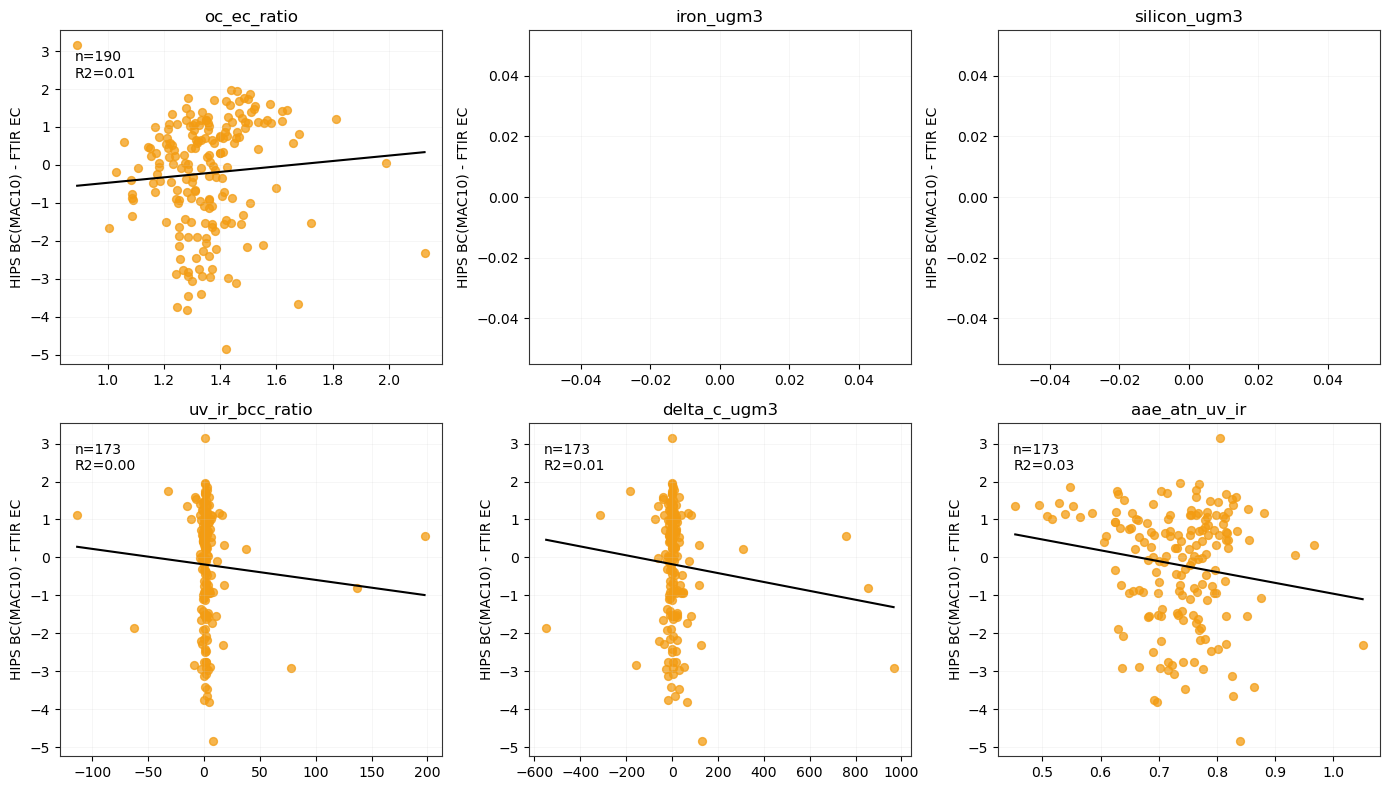

In [4]:
focus = m[m["site"] == "Addis_Ababa"].copy()
plot_vars = ["oc_ec_ratio", "iron_ugm3", "silicon_ugm3", "uv_ir_bcc_ratio", "delta_c_ugm3", "aae_atn_uv_ir"]
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, pred in zip(axes.flat, plot_vars):
    d = focus[[pred, "hips_minus_ftir"]].dropna()
    ax.scatter(d[pred], d["hips_minus_ftir"], s=32, alpha=0.75, color=SITE_COLORS["Addis_Ababa"])
    if len(d) >= 3:
        lr = stats.linregress(d[pred], d["hips_minus_ftir"])
        xs = np.linspace(d[pred].min(), d[pred].max(), 100)
        ax.plot(xs, lr.intercept + lr.slope * xs, color="black", lw=1.5)
        ax.text(0.04, 0.94, f"n={len(d)}\nR2={lr.rvalue**2:.2f}", transform=ax.transAxes, va="top")
    ax.set_title(pred)
    ax.set_ylabel("HIPS BC(MAC10) - FTIR EC")
    ax.grid(True, alpha=0.25)
plt.tight_layout()
fig_path = OUT_DIR / "addis_hips_residual_vs_chemistry_spectral_metrics.png"
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
print(fig_path)
plt.show()
